# OIBSIP INTERNSHIP TASK NO 1:
**Iris Flower Classification BY M WARID ALI**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

1.LOAD DATA

In [3]:
df = pd.read_csv('/content/Iris.csv')
df.drop(columns=['Id'], inplace=True)

print("Shape:", df.shape)
print("\nClass distribution:\n", df['Species'].value_counts())
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:", df.isnull().sum().sum())

Shape: (150, 5)

Class distribution:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

First 5 rows:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

Missing values: 0


2.EDA PLOT

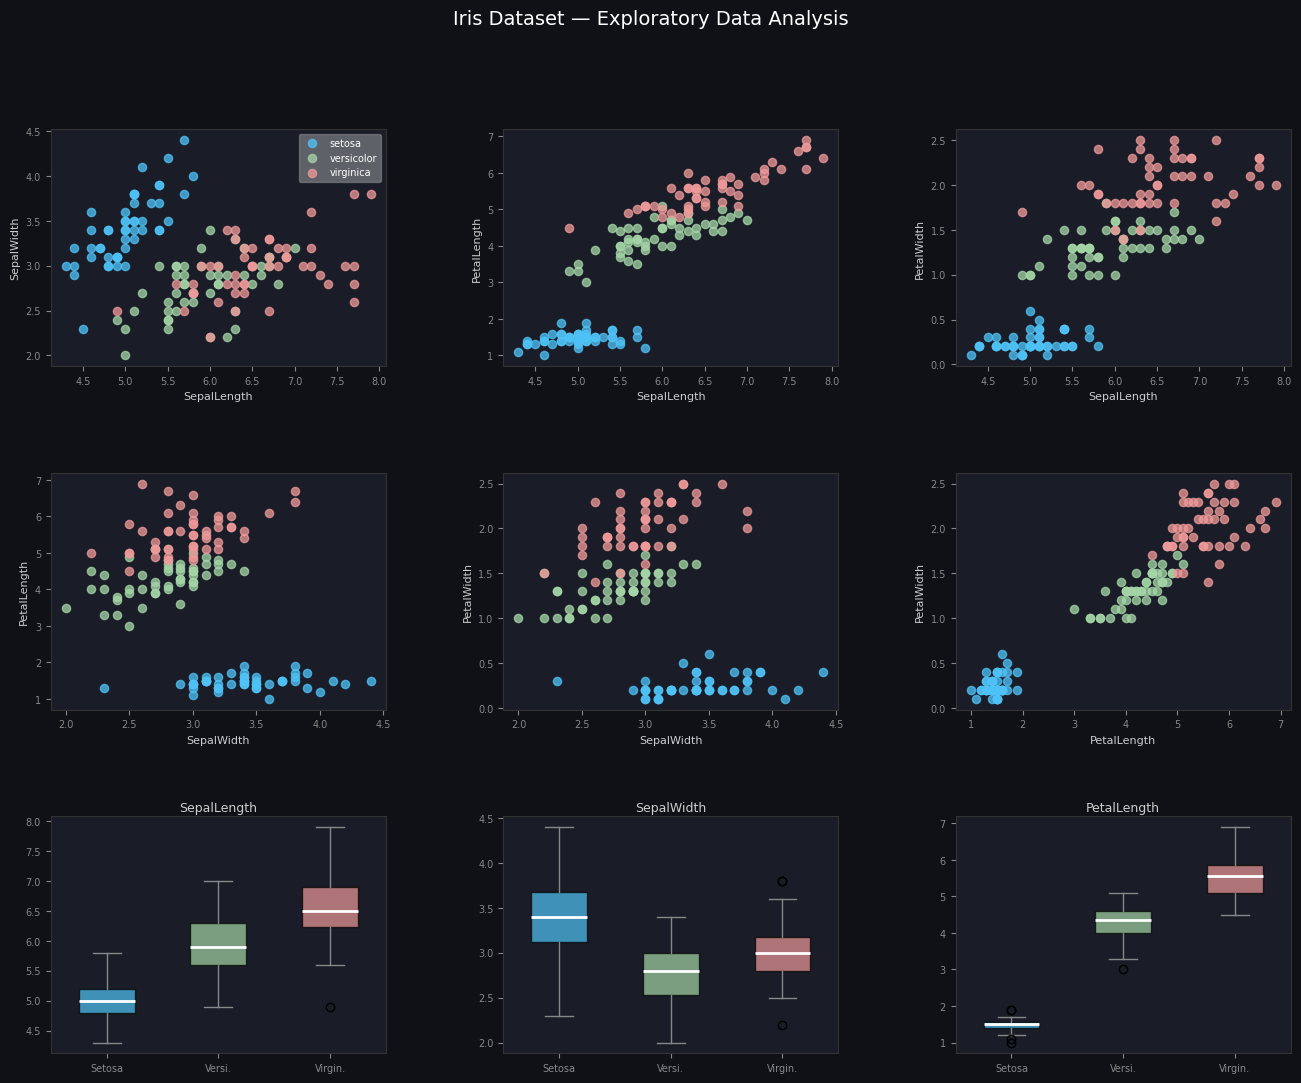

In [11]:
import os

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

palette = {'Iris-setosa': '#4fc3f7', 'Iris-versicolor': '#a5d6a7', 'Iris-virginica': '#ef9a9a'}
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Pairplot-style scatter (6 combos in top 2 rows)
combos = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
for idx, (xi, yi) in enumerate(combos):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    for sp, color in palette.items():
        subset = df[df['Species'] == sp]
        ax.scatter(subset[features[xi]], subset[features[yi]],
                   color=color, alpha=0.75, s=35, label=sp.replace('Iris-',''))
    ax.set_xlabel(features[xi].replace('Cm',''), color='#ccc', fontsize=8)
    ax.set_ylabel(features[yi].replace('Cm',''), color='#ccc', fontsize=8)
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#888', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#333')
    if idx == 0:
        ax.legend(fontsize=7, framealpha=0.3, labelcolor='white')

# Bottom row: box plots for first 3 features
for i, feat in enumerate(features[:3]):
    ax = fig.add_subplot(gs[2, i])
    data_by_species = [df[df['Species']==sp][feat].values for sp in palette.keys()]
    bp = ax.boxplot(data_by_species, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    colors = list(palette.values())
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for element in ['whiskers','caps','fliers']:
        for item in bp[element]: item.set_color('#888')
    ax.set_xticklabels(['Setosa','Versi.','Virgin.'], color='#ccc', fontsize=8)
    ax.set_title(feat.replace('Cm',''), color='#ccc', fontsize=9, pad=4)
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#888', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Iris Dataset — Exploratory Data Analysis', color='white', fontsize=14, y=0.98)

output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)
plt.show()

3.PREPROCESSING

In [7]:
X = df.drop('Species', axis=1)
le = LabelEncoder()
y = le.fit_transform(df['Species'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

4.TRAIN MULTIPLE MODELS


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f"{name:22s} → Accuracy: {acc*100:.2f}%")

best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
best_preds = results[best_name]['preds']
print(f"\n Best model: {best_name} ({results[best_name]['accuracy']*100:.2f}%)")

Logistic Regression    → Accuracy: 96.67%
Decision Tree          → Accuracy: 93.33%
Random Forest          → Accuracy: 90.00%
SVM                    → Accuracy: 96.67%

 Best model: Logistic Regression (96.67%)


5.RESULTS PLOT

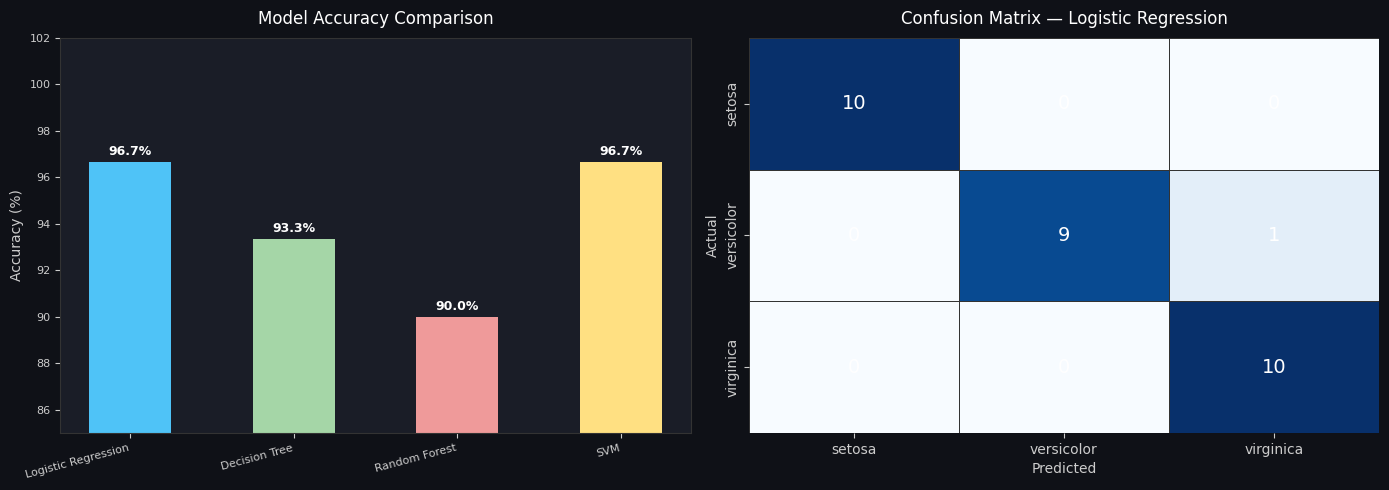

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Accuracy bar chart
ax = axes[0]
names = list(results.keys())
accs  = [results[n]['accuracy']*100 for n in names]
bar_colors = ['#4fc3f7','#a5d6a7','#ef9a9a','#ffe082']
bars = ax.bar(names, accs, color=bar_colors, width=0.5, edgecolor='none')
ax.set_ylim(85, 102)
ax.set_facecolor('#1a1d27')
ax.set_title('Model Accuracy Comparison', color='white', fontsize=12, pad=10)
ax.set_ylabel('Accuracy (%)', color='#ccc')
ax.tick_params(colors='#ccc', labelsize=8)
ax.set_xticklabels(names, rotation=15, ha='right', color='#ccc')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', color='white', fontsize=9, fontweight='bold')

# Confusion matrix for best model
ax = axes[1]
cm = confusion_matrix(y_test, best_preds)
class_names = [c.replace('Iris-','') for c in le.classes_]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, cbar=False,
            annot_kws={'size':14, 'color':'white'},
            linewidths=0.5, linecolor='#333')
ax.set_facecolor('#1a1d27')
ax.set_title(f'Confusion Matrix — {best_name}', color='white', fontsize=12, pad=10)
ax.set_xlabel('Predicted', color='#ccc'); ax.set_ylabel('Actual', color='#ccc')
ax.tick_params(colors='#ccc')

plt.tight_layout()
plt.show()


6.CLASSIFICATION REPORT

In [10]:
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, best_preds, target_names=le.classes_))



Classification Report — Logistic Regression:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

